# 4.0 — Pipeline Metrics: PPE Compliance Accuracy & People Counting MAE

Evaluate the two **pipeline-level metrics** defined in `README.md` that complement
detection-level mAP/Precision/Recall:

1. **PPE Compliance Accuracy** (target ≥ 85%) — per-person safe/violation classification
2. **People Counting Accuracy — MAE** (target ≤ 2 persons) — average error in person count per image

Uses the best model from notebook 3.1 (`resplit-oversample-conservative`) on the **test set**.

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib opencv-python-headless albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.0 MB/s eta 0:00:00


In [2]:
# @title Mount Drive or clone repo
import os
from pathlib import Path
import sys

!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")

Cloning into 'AlGear'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 155 (delta 5), reused 22 (delta 4), pack-reused 128 (from 1)
Receiving objects: 100% (155/155), 102.82 MiB | 20.66 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Updating files: 100% (41/41), done.
Project root: /content/AlGear


In [ ]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""

from algear.config import ROBOFLOW_DIR, ROBOFLOW_API_KEY
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Dataset at: {ROBOFLOW_DIR}")

2026-06-23 02:44:06.527 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Dataset at: /content/AlGear/data/raw/construction-safety-gsnvb


In [4]:
# @title Download dataset (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-23 02:44:07.119 | INFO     | algear.dataset:download_roboflow:35 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 4551.21it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-23 02:44:27.705 | SUCCESS  | algear.dataset:download_roboflow:39 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


In [5]:
# @title Check GPU availability
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## 1. Resplit Dataset

If the resplit dataset doesn't exist yet, run notebook 3.0 first.

In [6]:
# @title Resplit dataset (skip if already done)
from algear.dataset import resplit

RESPLIT_DIR = PROJECT_DIR / "data" / "processed" / "construction-site-safety-resplit"

if not (RESPLIT_DIR / "data.yaml").exists():
    print("Running resplit...")
    resplit(
        src_dir=ROBOFLOW_DIR,
        output_dir=RESPLIT_DIR,
        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        seed=42,
    )
else:
    print(f"Resplit dataset already exists at {RESPLIT_DIR}")

Running resplit...
2026-06-23 02:44:27.962 | INFO     | algear.dataset:resplit:154 - Collecting image-label pairs from all splits...
2026-06-23 02:44:29.606 | INFO     | algear.dataset:resplit:182 - Total unique pairs: 1206, duplicates skipped: 0
2026-06-23 02:44:29.795 | INFO     | algear.dataset:resplit:197 - Unique class signatures: 19
2026-06-23 02:44:29.796 | DEBUG    | algear.dataset:resplit:200 -     517 images — ['helmet', 'person', 'vest']
2026-06-23 02:44:29.797 | DEBUG    | algear.dataset:resplit:200 -     368 images — ['helmet', 'no-vest', 'person']
2026-06-23 02:44:29.797 | DEBUG    | algear.dataset:resplit:200 -     127 images — ['helmet', 'person']
2026-06-23 02:44:29.797 | DEBUG    | algear.dataset:resplit:200 -      59 images — ['helmet', 'no-vest', 'person', 'vest']
2026-06-23 02:44:29.797 | DEBUG    | algear.dataset:resplit:200 -      29 images — ['person']
2026-06-23 02:44:29.797 | DEBUG    | algear.dataset:resplit:200 -      21 images — ['helmet', 'no-helmet', 'no-

In [7]:
# @title Set paths
MODEL_PATH = PROJECT_DIR / "models" / "resplit-oversample-conservative" / "weights" / "best.pt"
TEST_IMAGE_DIR = RESPLIT_DIR / "test" / "images"
TEST_LABEL_DIR = RESPLIT_DIR / "test" / "labels"

assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert TEST_IMAGE_DIR.exists(), f"Test images not found: {TEST_IMAGE_DIR}"
assert TEST_LABEL_DIR.exists(), f"Test labels not found: {TEST_LABEL_DIR}"

print(f"Model: {MODEL_PATH}")
print(f"Test images: {TEST_IMAGE_DIR}")
print(f"Test labels: {TEST_LABEL_DIR}")

Model: /content/AlGear/models/resplit-oversample-conservative/weights/best.pt
Test images: /content/AlGear/data/processed/construction-site-safety-resplit/test/images
Test labels: /content/AlGear/data/processed/construction-site-safety-resplit/test/labels


## 2. Run Inference on Test Set

In [8]:
# @title Run inference on all test images
from algear.modeling.predict import run_inference

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
test_images = sorted(f for f in TEST_IMAGE_DIR.iterdir() if f.suffix.lower() in IMAGE_EXTS)
print(f"Test images: {len(test_images)}")

pred_results = run_inference(
    model_path=MODEL_PATH,
    image_dir=TEST_IMAGE_DIR,
    conf=0.25,
    device=device,
)

print(f"Results for {len(pred_results)} images")

Test images: 198
2026-06-23 02:44:37.611 | INFO     | algear.modeling.predict:run_inference:60 - Running inference on 198 images from /content/AlGear/data/processed/construction-site-safety-resplit/test/images


Inference: 100%|██████████| 198/198 [02:02<00:00,  1.62it/s]

2026-06-23 02:46:40.052 | SUCCESS  | algear.modeling.predict:run_inference:102 - Inference complete: 198 images processed
Results for 198 images


## 3. People Counting MAE

In [10]:
import numpy as np
# @title Count GT persons per image
PERSON_CLASS = 3

def count_persons_in_label(label_path: Path) -> int:
    """Count person instances in a YOLO label file."""
    if not label_path.exists():
        return 0
    count = 0
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5 and int(parts[0]) == PERSON_CLASS:
                count += 1
    return count

gt_counts = []
for img_path in test_images:
    label_path = TEST_LABEL_DIR / f"{img_path.stem}.txt"
    gt_counts.append(count_persons_in_label(label_path))

print(f"GT person counts — total: {sum(gt_counts)}, mean: {np.mean(gt_counts):.1f}, max: {max(gt_counts)}")

GT person counts — total: 484, mean: 2.4, max: 12


In [11]:
# @title Count predicted persons per image
pred_counts = []
for r in pred_results:
    if len(r["detections"]) == 0:
        pred_counts.append(0)
    else:
        pred_counts.append(int((r["detections"][:, 0] == PERSON_CLASS).sum()))

print(f"Pred person counts — total: {sum(pred_counts)}, mean: {np.mean(pred_counts):.1f}, max: {max(pred_counts)}")

Pred person counts — total: 648, mean: 3.3, max: 23


In [12]:
# @title Compute People Counting MAE
from algear.metrics import people_counting_mae

mae_result = people_counting_mae(gt_counts, pred_counts)

print(f"\n=== People Counting Results ===")
print(f"MAE:              {mae_result['mae']:.2f}  (target: \u2264 2)")
print(f"Mean GT count:    {mae_result['mean_gt']:.1f}")
print(f"Mean pred count:  {mae_result['mean_pred']:.1f}")
print(f"Max error:        {mae_result['max_error']}")
print(f"Status:           {'\u2705 PASS' if mae_result['mae'] <= 2 else '\u274c FAIL'}")

2026-06-23 02:47:43.183 | INFO     | algear.metrics:people_counting_mae:135 - People Counting MAE: 0.87 (target: ≤ 2)
2026-06-23 02:47:43.183 | INFO     | algear.metrics:people_counting_mae:136 -   Mean GT count: 2.4, Mean pred count: 3.3
2026-06-23 02:47:43.183 | INFO     | algear.metrics:people_counting_mae:137 -   Max single-image error: 12

=== People Counting Results ===
MAE:              0.87  (target: ≤ 2)
Mean GT count:    2.4
Mean pred count:  3.3
Max error:        12
Status:           ✅ PASS


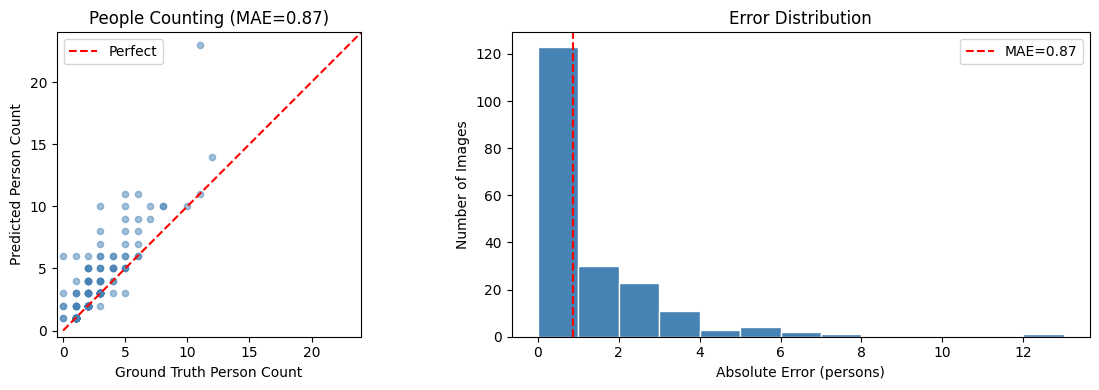

In [13]:
# @title Visualise People Counting results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: GT vs Predicted
axes[0].scatter(gt_counts, pred_counts, alpha=0.5, s=20, c="steelblue")
max_val = max(max(gt_counts), max(pred_counts)) + 1
axes[0].plot([0, max_val], [0, max_val], "r--", label="Perfect")
axes[0].set_xlabel("Ground Truth Person Count")
axes[0].set_ylabel("Predicted Person Count")
axes[0].set_title(f"People Counting (MAE={mae_result['mae']:.2f})")
axes[0].legend()
axes[0].set_xlim(-0.5, max_val)
axes[0].set_ylim(-0.5, max_val)
axes[0].set_aspect("equal")

# Error distribution
errors = [r["error"] for r in mae_result["per_image"]]
axes[1].hist(errors, bins=range(0, max(errors) + 2), color="steelblue", edgecolor="white")
axes[1].axvline(mae_result["mae"], color="red", linestyle="--", label=f"MAE={mae_result['mae']:.2f}")
axes[1].set_xlabel("Absolute Error (persons)")
axes[1].set_ylabel("Number of Images")
axes[1].set_title("Error Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. PPE Compliance Accuracy

In [14]:
# @title Compute PPE Compliance Accuracy
from algear.metrics import ppe_compliance_accuracy

compliance_result = ppe_compliance_accuracy(
    gt_labels_dir=TEST_LABEL_DIR,
    pred_results=pred_results,
    img_dir=TEST_IMAGE_DIR,
)

print(f"\n=== PPE Compliance Results ===")
print(f"Accuracy:         {compliance_result['accuracy']:.1%}  (target: \u2265 85%)")
print(f"Total persons:    {compliance_result['total_persons']}")
print(f"Correct:          {compliance_result['correct']}")
print(f"Status:           {'\u2705 PASS' if compliance_result['accuracy'] >= 0.85 else '\u274c FAIL'}")

2026-06-23 02:48:02.760 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 3 persons — 0 compliant, 3 violations
2026-06-23 02:48:02.763 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 9 persons — 5 compliant, 4 violations
2026-06-23 02:48:02.766 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 5 persons — 5 compliant, 0 violations
2026-06-23 02:48:02.767 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 1 persons — 0 compliant, 1 violations
2026-06-23 02:48:02.767 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 1 persons — 0 compliant, 1 violations
2026-06-23 02:48:02.768 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 2 persons — 2 compliant, 0 violations
2026-06-23 02:48:02.768 | DEBUG    | algear.modeling.pipeline:associate_ppe_to_persons:152 - Associated 2 persons — 0 compliant, 2 violations
2026-0

In [15]:
# @title Per-image compliance detail
per_img = compliance_result["per_image"]
images_with_errors = [p for p in per_img if p["gt_persons"] > 0 and p["correct"] < p["total"]]
print(f"Images with compliance errors: {len(images_with_errors)} / {len(per_img)}")

# Worst cases
worst = sorted(per_img, key=lambda x: x["total"] - x["correct"], reverse=True)[:10]
print("\nWorst 10 images (most misclassifications):")
print(f"{'Image':<35s} {'GT':>4s} {'Pred':>5s} {'Correct':>7s} {'Total':>5s}")
for w in worst:
    print(f"{w['image']:<35s} {w['gt_persons']:>4d} {w['pred_persons']:>5d} {w['correct']:>7d} {w['total']:>5d}")

Images with compliance errors: 101 / 198

Worst 10 images (most misclassifications):
Image                                 GT  Pred Correct Total
ppe_0720_jpg.rf.f97def9daff3143f44dac7cf734e4303.jpg   11    23       1    23
ppe_0100_jpg.rf.f164f8f44d6ea40759a4221c899c5ba3.jpg    5    11       1    11
ppe_0899_jpg.rf.6416dc037fb655380ce8c4e097faa9f4.jpg    3    10       1    10
ppe_0229_jpg.rf.b73a016b877f48c93e9e99ec4e346d21.jpg    5     9       1     9
ppe_0016_jpg.rf.34aaa4aae89d10b1c9029efaaba2a114.jpg    7     9       2     9
ppe_1140_jpg.rf.f36f0d861d83858f6ba6861850e9b1a6.jpg    3     8       1     8
ppe_0206_jpg.rf.46a1af29e498f91d39764e168a1b6322.jpg   10    10       4    10
ppe_0532_jpg.rf.aec9574142bf4b6c68c4e0342c57820b.jpg    0     6       0     6
ppe_1010_jpg.rf.5009add0f4b877957986095d83e8f204.jpg    6    11       5    11
ppe_0033_jpg.rf.8c43571990c9f1f32f8673f4c7b2d455.jpg    5     5       0     5


Displaying the worst 2 misclassified images with predicted person bounding boxes...


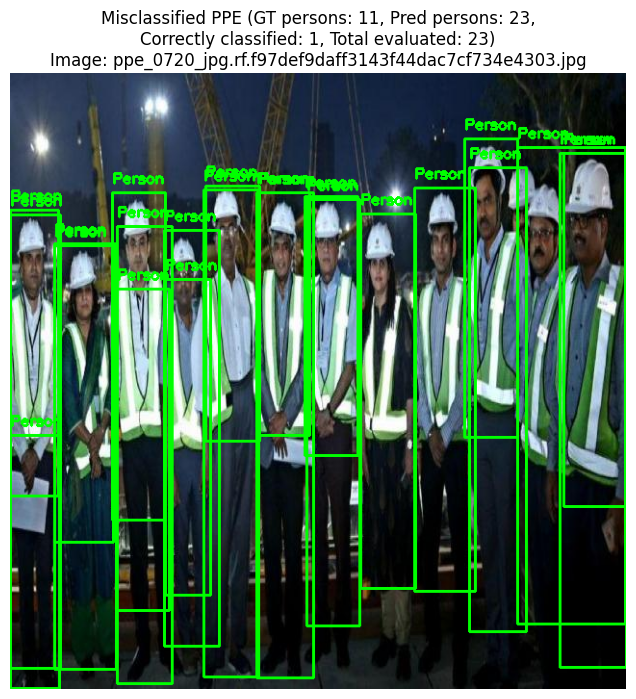

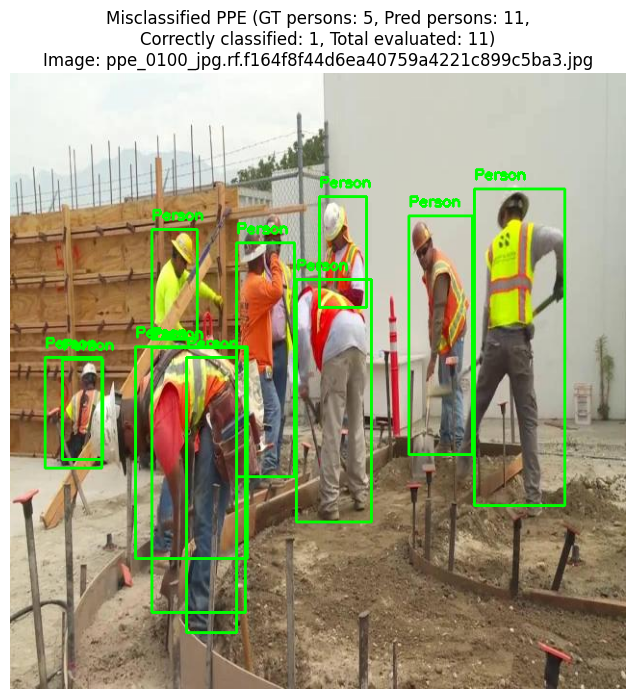

In [22]:
import cv2
import matplotlib.pyplot as plt

print(f"Displaying the worst {min(2, len(worst))} misclassified images with predicted person bounding boxes...")

for i, error_info in enumerate(worst[:2]): # Display worst 2
    image_name = error_info["image"]
    image_path = TEST_IMAGE_DIR / image_name

    img = cv2.imread(str(image_path))
    if img is None:
        print(f"Could not load image: {image_path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Find the corresponding prediction result for this image
    current_pred_result = next((pr for pr in pred_results if pr["image_name"] == image_name), None)

    if current_pred_result:
        # Get image dimensions
        img_h, img_w, _ = img_rgb.shape

        # Filter for person detections (PERSON_CLASS is 3)
        # Detections are [class_id, x_center_norm, y_center_norm, width_norm, height_norm]
        person_detections = current_pred_result["detections"][current_pred_result["detections"][:, 0] == PERSON_CLASS]

        for det in person_detections:
            # Unpack normalized bounding box coordinates
            _, x_center_norm, y_center_norm, width_norm, height_norm = det

            # Convert normalized coordinates to pixel coordinates
            x_center_pixel = x_center_norm * img_w
            y_center_pixel = y_center_norm * img_h
            width_pixel = width_norm * img_w
            height_pixel = height_norm * img_h

            x_min = int(x_center_pixel - width_pixel / 2)
            y_min = int(y_center_pixel - height_pixel / 2)
            x_max = int(x_center_pixel + width_pixel / 2)
            y_max = int(y_center_pixel + height_pixel / 2)

            # Draw bounding box (green color, thickness 2)
            cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
            # Optionally add label text
            cv2.putText(img_rgb, "Person", (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title(f"Misclassified PPE (GT persons: {error_info['gt_persons']}, Pred persons: {error_info['pred_persons']},\nCorrectly classified: {error_info['correct']}, Total evaluated: {error_info['total']})\nImage: {image_name}")
    plt.axis('off')
    plt.show()


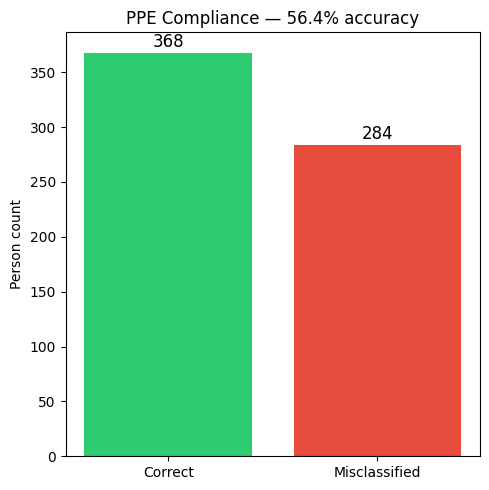

In [16]:
# @title Visualise PPE Compliance results
n_correct = compliance_result["correct"]
n_total = compliance_result["total_persons"]
n_wrong = n_total - n_correct

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(["Correct", "Misclassified"], [n_correct, n_wrong], color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Person count")
ax.set_title(f"PPE Compliance \u2014 {compliance_result['accuracy']:.1%} accuracy")
for i, v in enumerate([n_correct, n_wrong]):
    ax.text(i, v + 5, str(v), ha="center", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Combined Metrics Summary

In [17]:
# @title Metrics summary table
print("=" * 70)
print("  PIPELINE METRICS SUMMARY  (Test Set)")
print("=" * 70)
print()
print(f"  {'Metric':<40s} {'Target':>10s} {'Result':>10s} {'Status':>6s}")
print(f"  {'-'*40} {'-'*10} {'-'*10} {'-'*6}")

mae_ok = mae_result["mae"] <= 2
acc_ok = compliance_result["accuracy"] >= 0.85

print(f"  {'People Counting MAE':<40s} {'\u2264 2':>10s} {mae_result['mae']:>10.2f} {'\u2705' if mae_ok else '\u274c':>6s}")
print(f"  {'PPE Compliance Accuracy':<40s} {'\u2265 85%':>10s} {compliance_result['accuracy']:>9.1%} {'\u2705' if acc_ok else '\u274c':>6s}")
print()

# Detection-level metrics from notebook 3.1
print("  Detection-level metrics (from notebook 3.1):")
print(f"  {'mAP@50 (overall)':<40s} {'\u2265 80%':>10s} {'81.0%':>10s} {'\u2705':>6s}")
print(f"  {'FNR no-helmet':<40s} {'\u2264 10%':>10s} {'36.2%':>10s} {'\u274c':>6s}")
print(f"  {'FNR no-vest':<40s} {'\u2264 10%':>10s} {'18.1%':>10s} {'\u274c':>6s}")
print()
print("=" * 70)

  PIPELINE METRICS SUMMARY  (Test Set)

  Metric                                       Target     Result Status
  ---------------------------------------- ---------- ---------- ------
  People Counting MAE                             ≤ 2       0.87      ✅
  PPE Compliance Accuracy                       ≥ 85%     56.4%      ❌

  Detection-level metrics (from notebook 3.1):
  mAP@50 (overall)                              ≥ 80%      81.0%      ✅
  FNR no-helmet                                 ≤ 10%      36.2%      ❌
  FNR no-vest                                   ≤ 10%      18.1%      ❌



In [18]:
# @title Download model (optional)
from google.colab import files
files.download(str(MODEL_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>